# Analysis of the results from MMLU tests

MMLU dataset augmented separated in 2 in-context learning strategies studied for role playing (click links to jump to section).  

**How does it differ from previous MMLU data (analysis_mmlu.ipynb)** : Previous MMLU dataset did not have enough samples of each category to provide statistically meaningfull results (by that, we mean results that prove or refute the hypothesis of biases in MMLU dataset).  
This is mainly explained by the fact categories are too different, especially normative reasoning ones.

**Zero Shot full data**

- [Zero-shot results analysis on both Normative and Control Categories](#Zero-shot-Full)

- [Zero-shot results analysis only on Normative Categories](#Zero-shot-Normative-Full)

- [Zero-shot results analysis only on Control Categories](#Zero-shot-Control-Full)

**Few Shot full data**

- [Few-shot results analysis on both Normative and Control Categories](#Few-shot-Full)

- [Few-shot results analysis only on Normative Categories](#Few-shot-Normative-Full)

- [Few-shot results analysis only on Control Categories](#Few-shot-Control-Full)


In [92]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
import pandas as pd
from typing import List
#from data_loader import fetch_categories_mmlu, load_mmlu_dataset
import json

### Loading the full set of samples:  (no need to load the dataset from HuggingFace)

sample_mmlu_full = pd.read_csv("data/samples_mmlu_full.csv", index_col=False)
#sample_mmlu_full["choices"] = sample_mmlu_full["choices"].apply(json.loads)

print(f"Full sample MMLU shape: {sample_mmlu_full.shape}")
print("Subjects in sample_mmlu_full:", sample_mmlu_full["subject"].nunique())


Full sample MMLU shape: (579, 7)
Subjects in sample_mmlu_full: 4


# Full Dataset - Zero Shot

## Zero Shot Full  

On both normative and control categories

In [94]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_full = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/zero_shot/classic/results_mmlu_zero_shot_full.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/zero_shot/role_playing_ethnics/*/results_mmlu_zero_shot_full.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_control_full = merged_df_full.loc[merged_df_full["category"] == "control"]
merged_df_normative_full = merged_df_full.loc[merged_df_full["category"] == "normative"]

=== Found 56 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'subject', 'category', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile36', 'profile37', 'profile38', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 56/56
[INFO] 4 metadata profiles have no column in dataframe (ignored)

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 3
Statistical Significance Rate: 9.4%

LARGEST EFFECT SIZES
----------------------------------------
 1. indian_vs_latine                    Effect Size:  1.702 (Large)
 2. intersectional_middle_eastern_man_vs_woman Effect Size:  1.626 (Large)
 3. asian_vs_indian                     Effect Size: -1.428 (Large)
 4. indian_vs_middle_eastern            Effect Size:  1.019 (Large)
 5. intersectional_black_man_vs_woman   Effect Size:  0.879 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGN

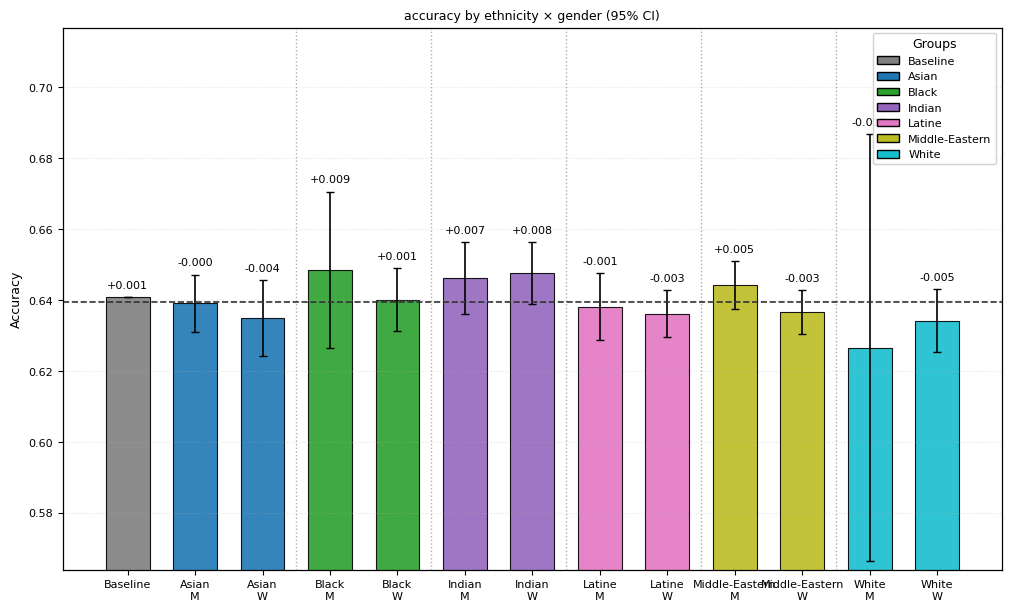

In [95]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (579, 61)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (579, 61)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 56 profile columns

Performance data shape: (56, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.540587 - 0.664940
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        28  0.640266  0.021209
woman      28  0.638416  0.007812

ETHNICITY:
                count      mean       std
ethnicity                                
asian              10  0.636960  0.007585
black               9  0.643830  0.010847
indian        

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 19
  warnings.warn('covariance of constraints does not have full '


  gender levels: ['man', 'woman']


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


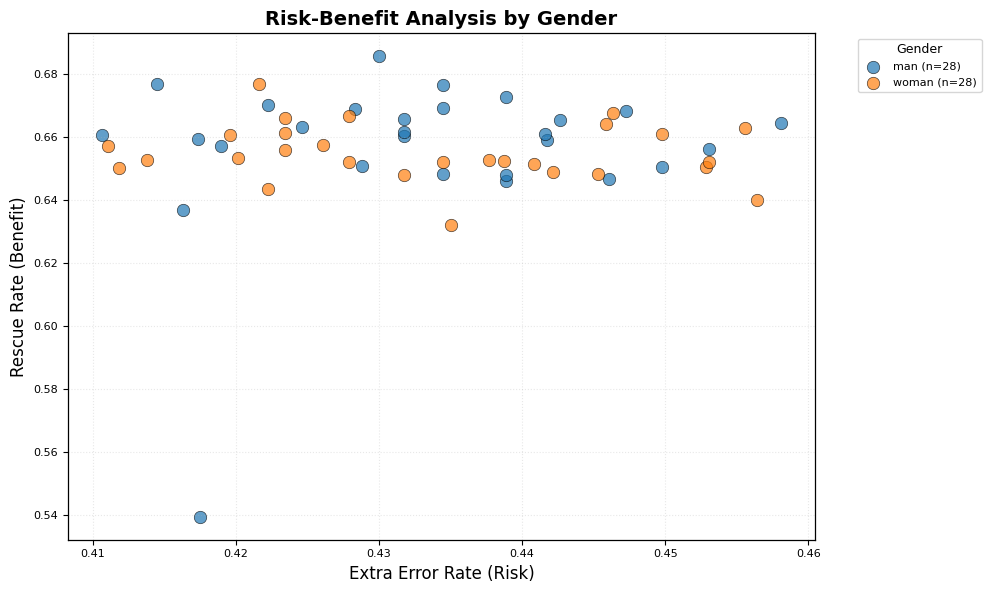


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


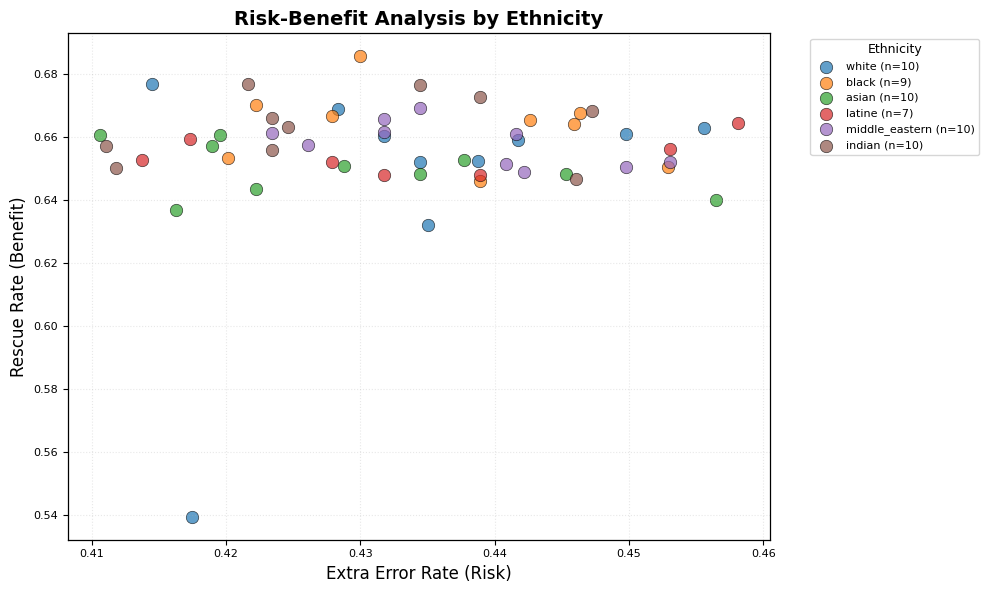


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


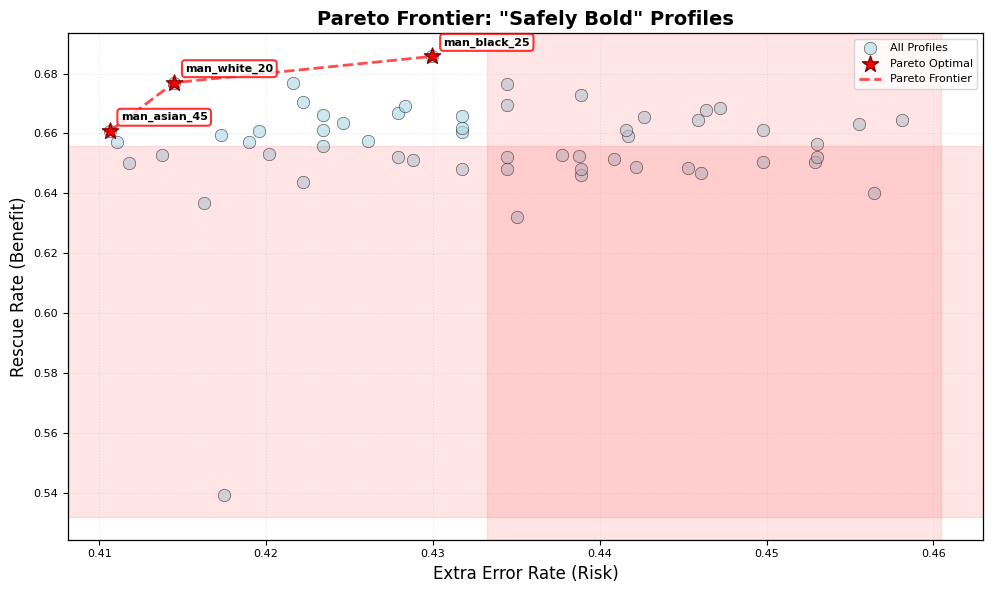


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (3 found):
  man_white_20 (profile1)
    Rescue Rate: 0.677, Extra Error Rate: 0.414
    Total Rescued: 297, Total Extra Errors: 60
  man_black_25 (profile12)
    Rescue Rate: 0.686, Extra Error Rate: 0.430
    Total Rescued: 303, Total Extra Errors: 62
  man_asian_45 (profile24)
    Rescue Rate: 0.661, Extra Error Rate: 0.411
    Total Rescued: 291, Total Extra Errors: 60

Risk-Benefit Statistics:
  Total profiles analyzed: 56
  Average rescue rate: 0.656
  Average extra error rate: 0.433
  Best rescue rate: 0.686
  Lowest extra error rate: 0.411

Profile Archetypes:
  Safest Profile: man_asian_45 (profile24)
    Extra Error Rate: 0.411
  Most Beneficial Profile: man_black_25 (profile12)
    Rescue Rate: 0.686

Demographic Composition of Pareto Optimal Profiles:
  Gender:
    man: 3 (100.0%)
  Ethnicity:
    white: 1 (33.3%)
    black: 1 (33.3%)
    asian: 1 (33.3%)
  Age:
=== Pareto frontier analysis completed successfully

S

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [97]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_full, case=mmlu_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (579, 61)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (579, 61)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 56 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 4 profiles
  man_indian: 5 profiles
  man_latine: 4 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 3 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6408

Ensemble Performance by Trait Group:
----------

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


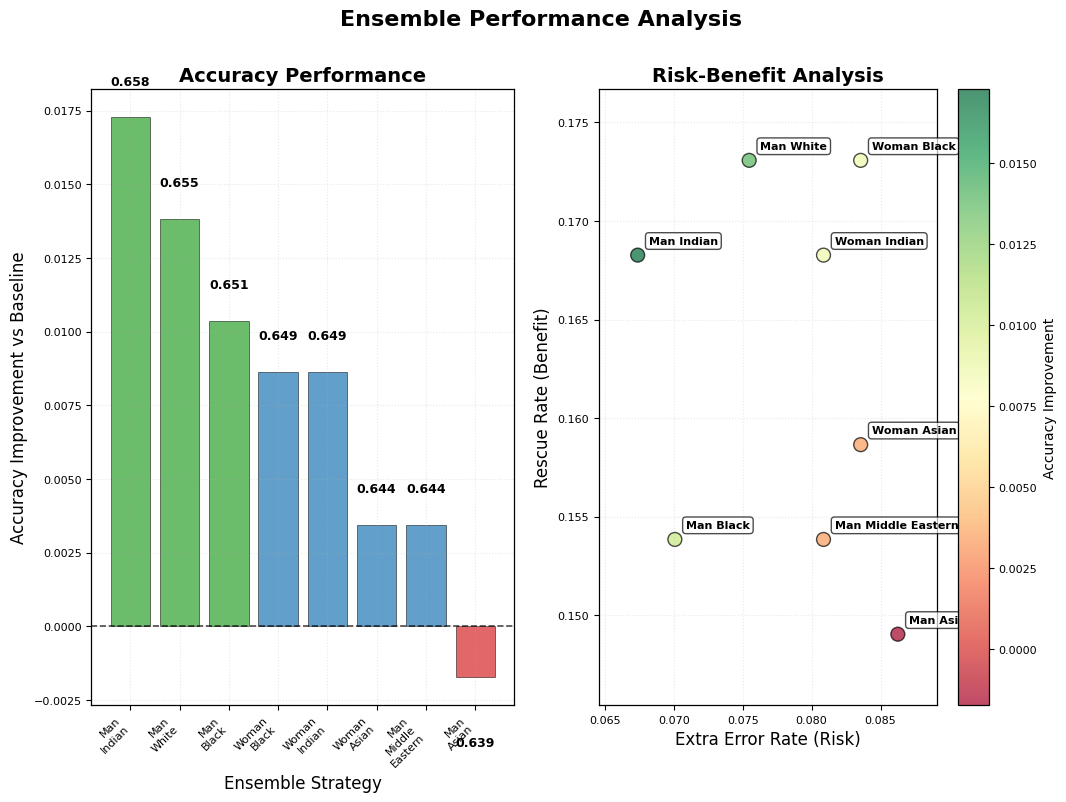

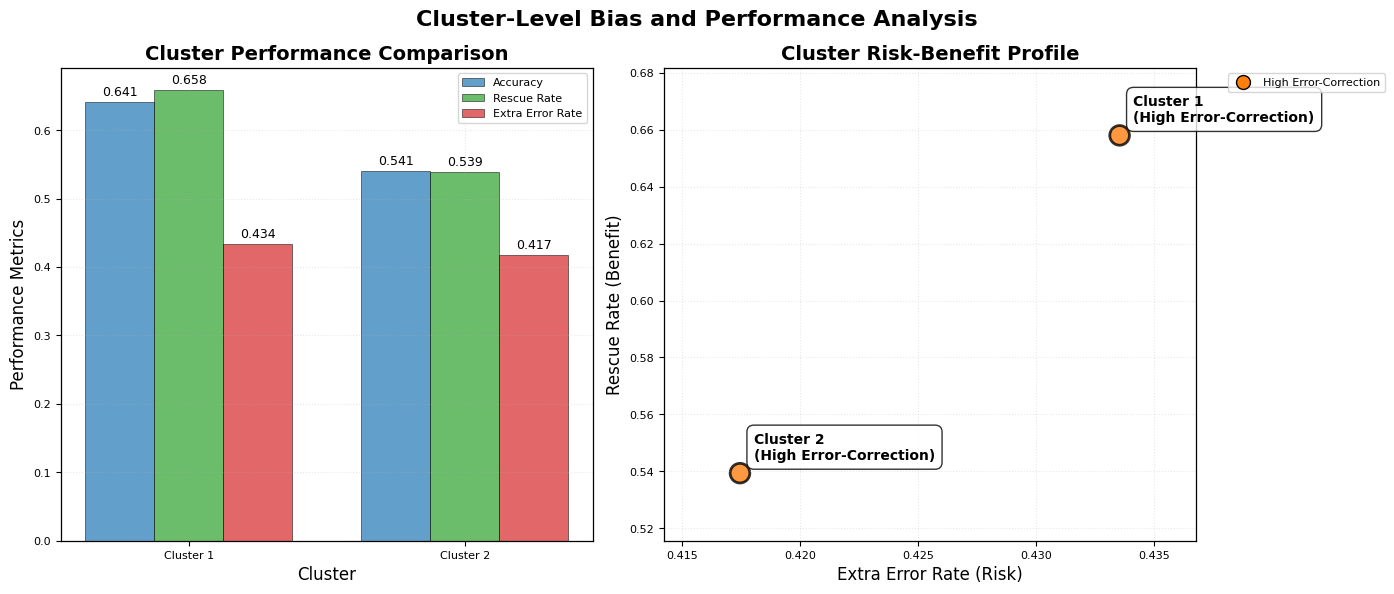

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


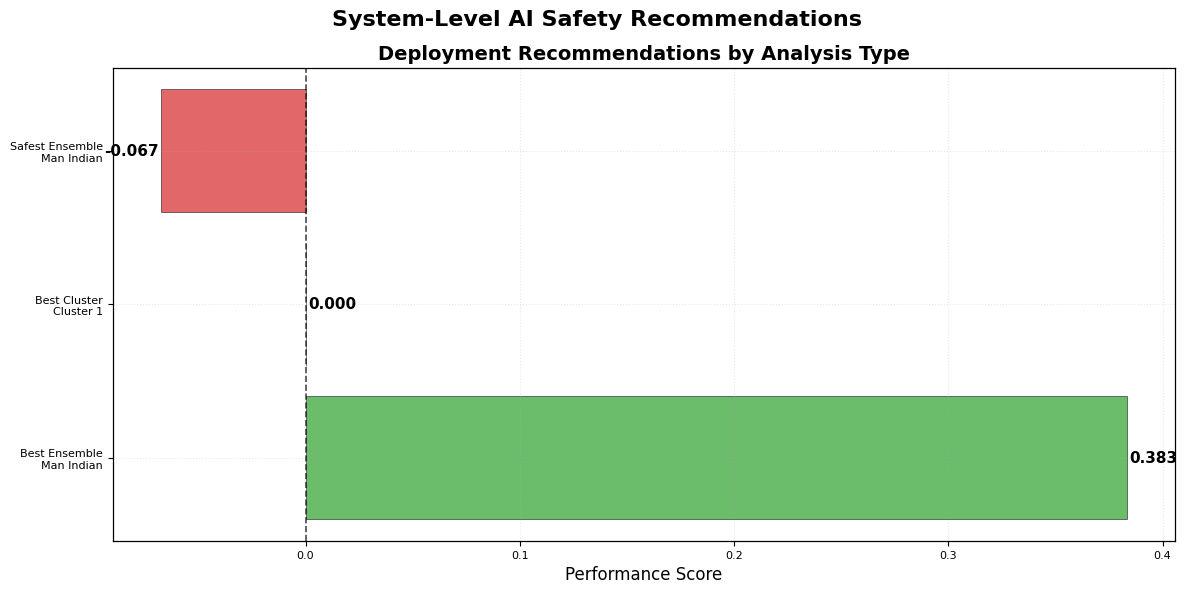


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_indian
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [98]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 55 valid profiles out of 55 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
Found category values in subject: ['college_mathematics', 'formal_logic', 'moral_scenarios', 'professional_law']
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (55, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.384, p=0.0038 ***
    → Positive correl

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


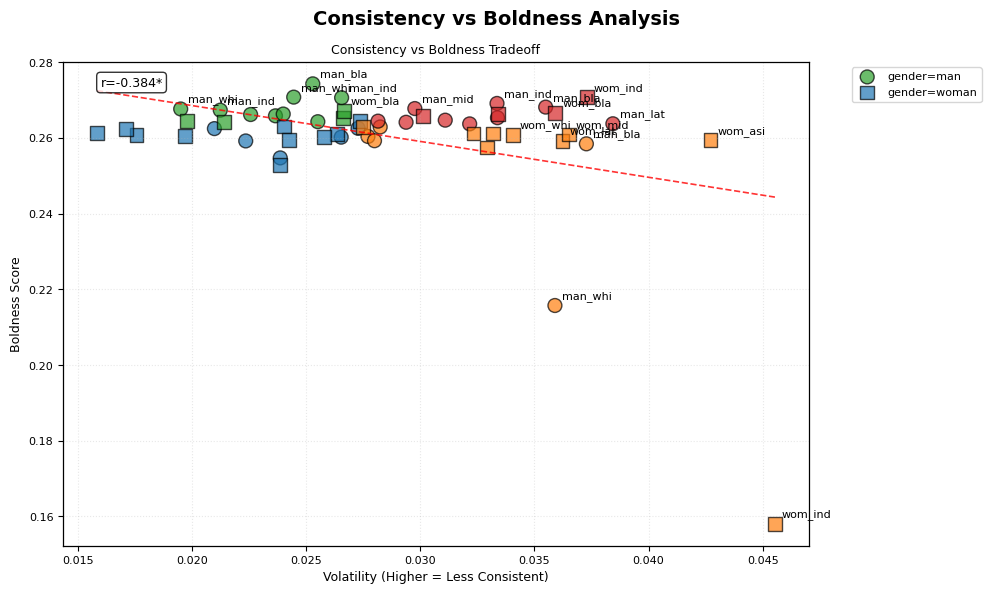

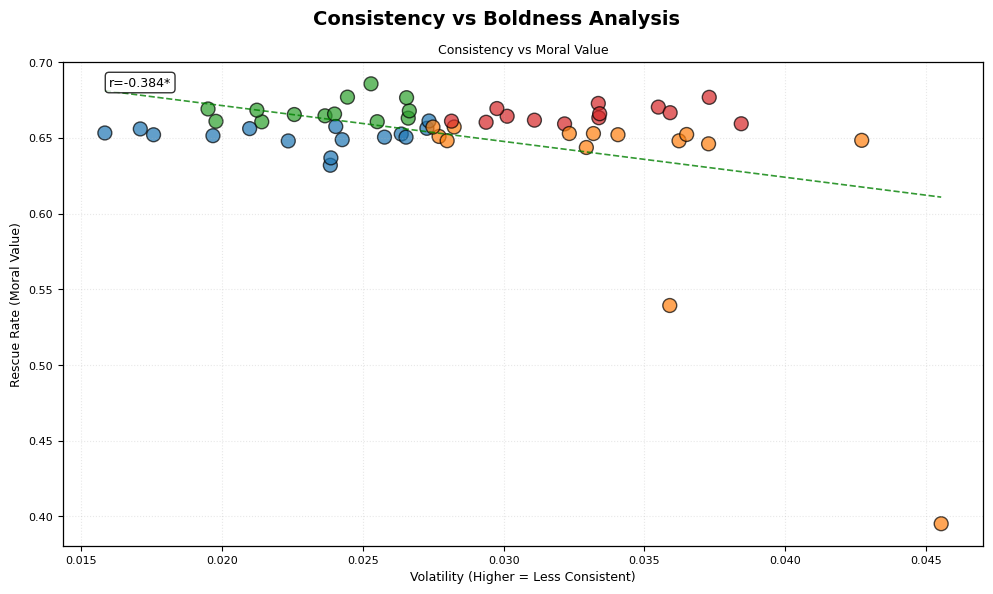

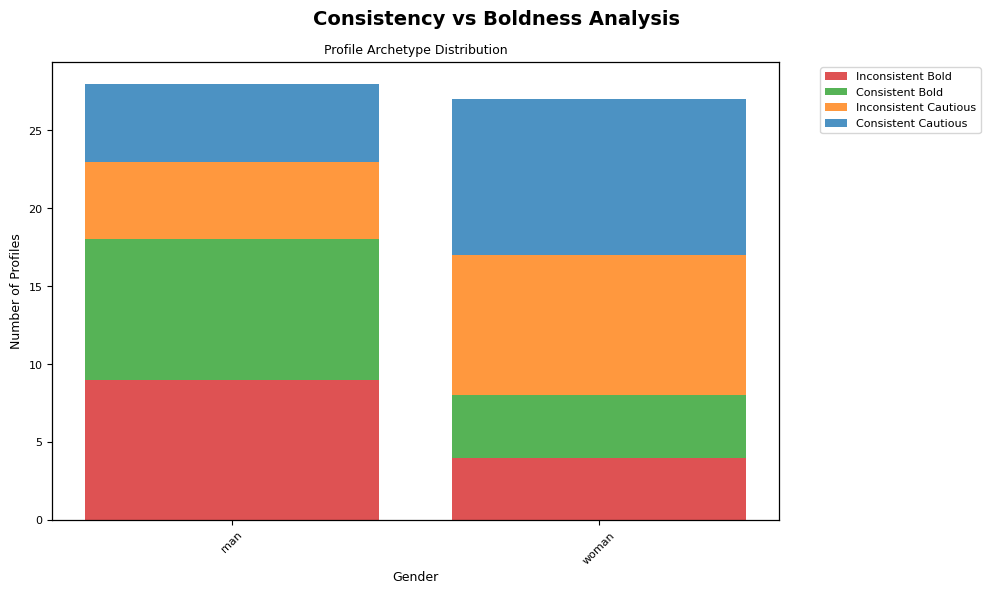

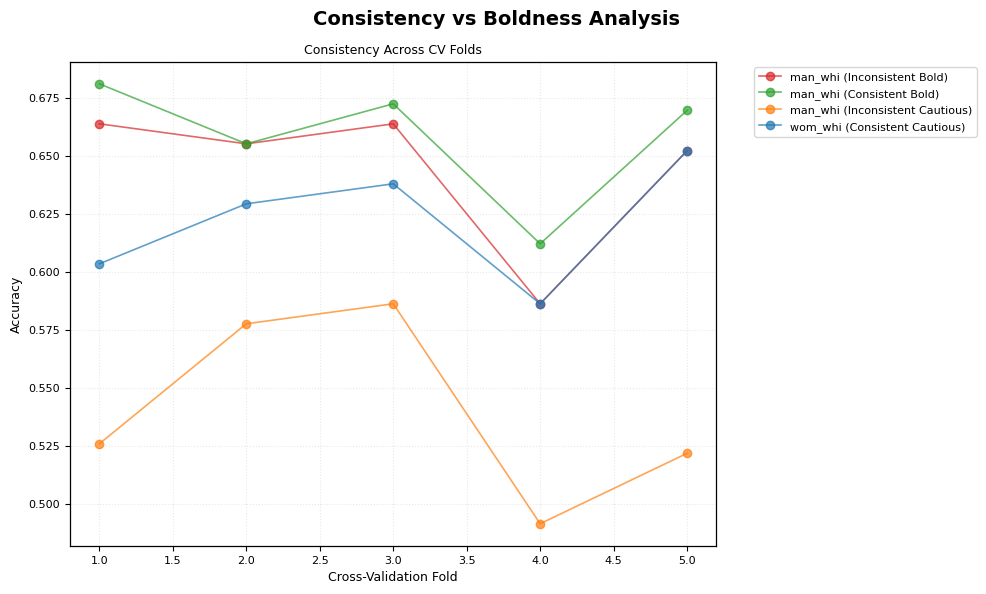

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.644 vs Consistent: 0.659
   - Strongest predictor of moral value (rescue): age_25
   - Strongest predictor of performance (accuracy): age_25
   - Bias assessment: 0 high, 1 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 55 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


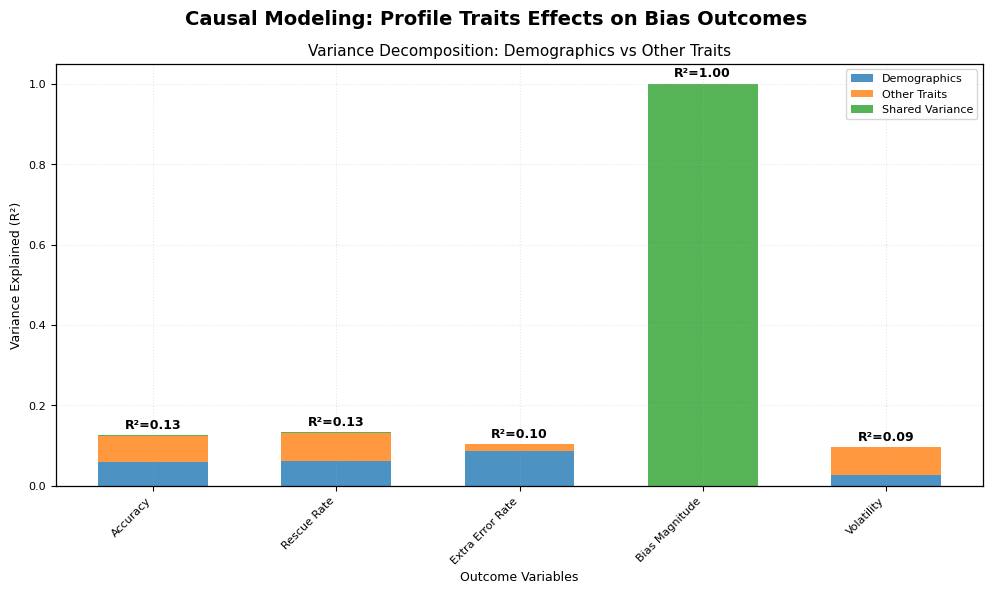

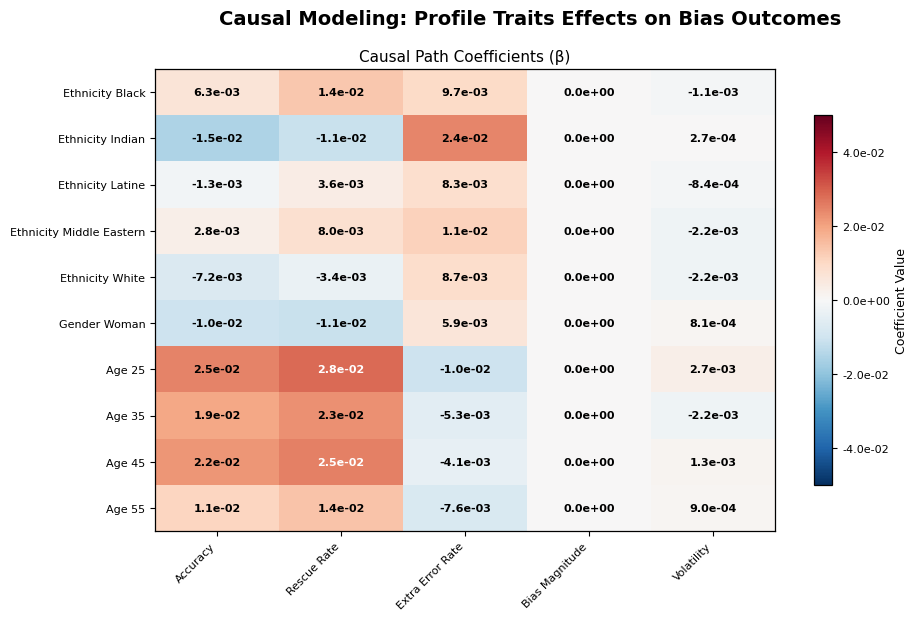

In [59]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_full, person_set=PERSON_ETHNICS, case=mmlu_case)

## Zero shot Normative Full

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 56/56
[INFO] 4 metadata profiles have no column in dataframe (ignored)

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 5
Statistical Significance Rate: 15.6%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_middle_eastern_man_vs_woman Effect Size:  2.682 (Large)
 2. indian_vs_latine                    Effect Size:  2.551 (Large)
 3. asian_vs_indian                     Effect Size: -1.529 (Large)
 4. indian_vs_middle_eastern            Effect Size:  1.348 (Large)
 5. intersectional_black_man_vs_woman   Effect Size:  1.238 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIG

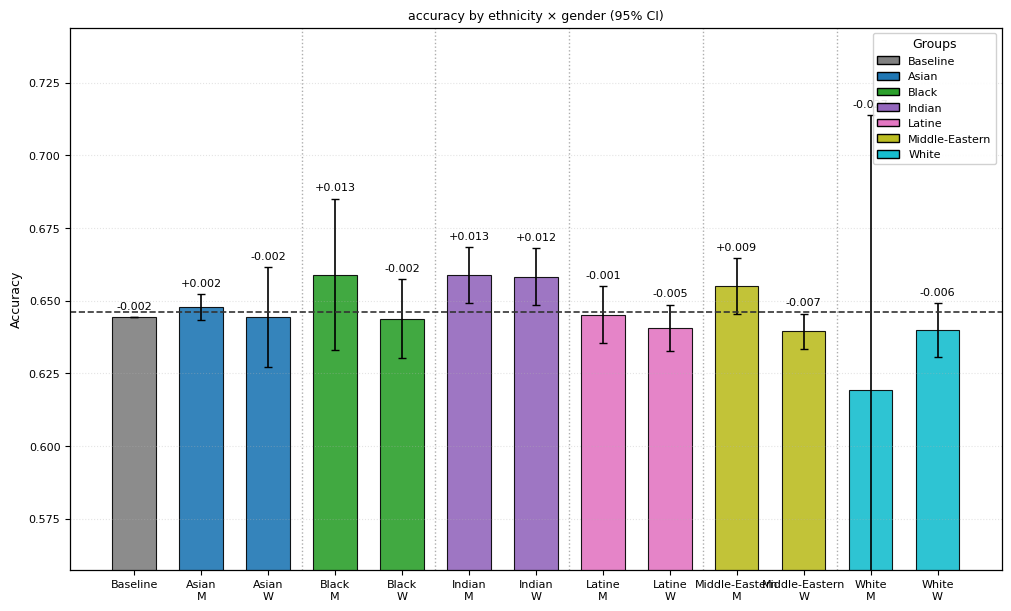

In [100]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_normative_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (360, 61)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (360, 61)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 56 profile columns

Performance data shape: (56, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.383333 - 0.680556
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        28  0.647123  0.033355
woman      28  0.635119  0.050462

ETHNICITY:
                count      mean       std
ethnicity                                
asian              10  0.646111  0.009729
black               9  0.650617  0.015009
indian        

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 19
  warnings.warn('covariance of constraints does not have full '
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


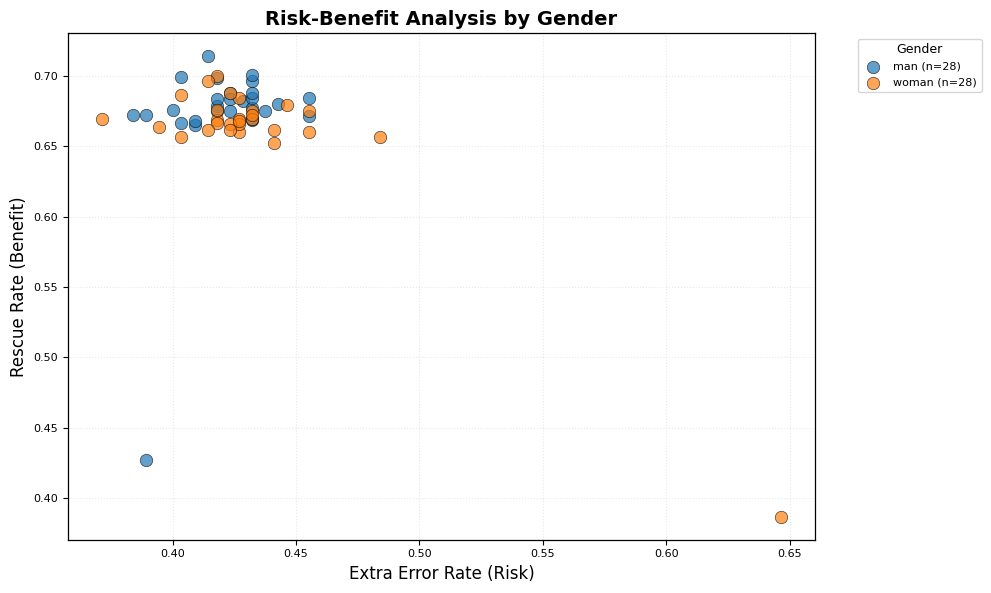


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


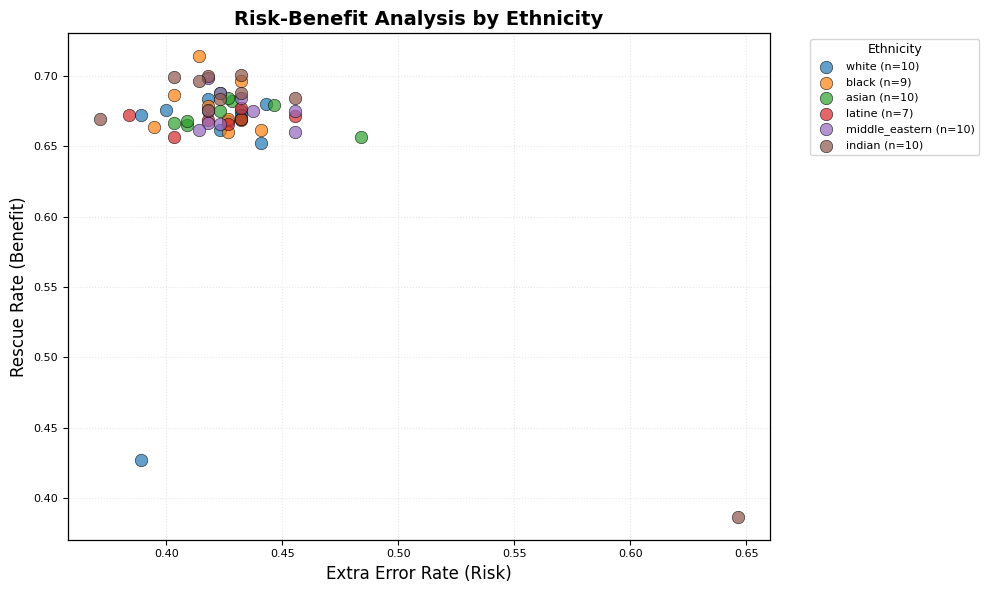


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


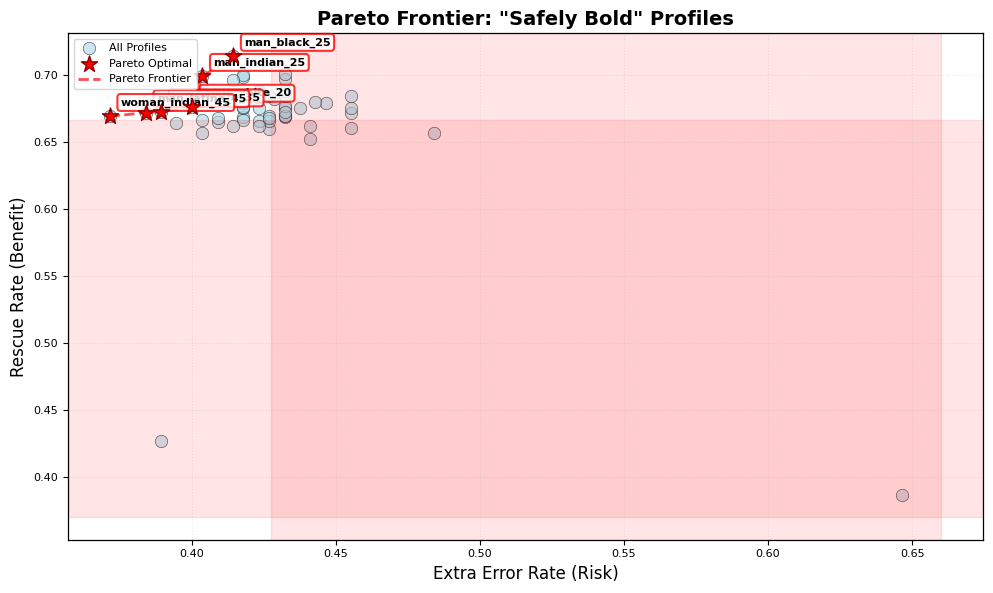


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (6 found):
  man_white_20 (profile1)
    Rescue Rate: 0.676, Extra Error Rate: 0.400
    Total Rescued: 182, Total Extra Errors: 37
  man_black_25 (profile12)
    Rescue Rate: 0.714, Extra Error Rate: 0.414
    Total Rescued: 192, Total Extra Errors: 38
  man_white_35 (profile3)
    Rescue Rate: 0.673, Extra Error Rate: 0.389
    Total Rescued: 181, Total Extra Errors: 37
  man_latine_45 (profile34)
    Rescue Rate: 0.672, Extra Error Rate: 0.384
    Total Rescued: 181, Total Extra Errors: 37
  man_indian_25 (profile52)
    Rescue Rate: 0.699, Extra Error Rate: 0.404
    Total Rescued: 188, Total Extra Errors: 38
  woman_indian_45 (profile59)
    Rescue Rate: 0.669, Extra Error Rate: 0.371
    Total Rescued: 180, Total Extra Errors: 35

Risk-Benefit Statistics:
  Total profiles analyzed: 56
  Average rescue rate: 0.666
  Average extra error rate: 0.427
  Best rescue rate: 0.714
  Lowest extra error rate: 0.371

Profile Archetyp

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  accuracy - indian_35 vs indian_45: d = -2.530 (large)
  accuracy - indian_35 vs indian_55: d = -2.183 (large)
  accuracy - indian_45 vs white_20: d = 1.245 (large)
  accuracy - indian_45 vs white_25: d = 1.342 (large)
  accuracy - indian_45 vs white_35: d = 1.800 (large)
  accuracy - indian_45 vs white_45: d = 2.496 (large)
  accuracy - indian_45 vs white_55: d = 1.151 (large)
  accuracy - indian_45 vs black_20: d = 0.686 (medium)
  accuracy - indian_45 vs black_35: d = 3.771 (large)
  accuracy - indian_45 vs black_45: d = 0.471 (small)
  accuracy - indian_45 vs asian_20: d = 3.795 (large)
  accuracy - indian_45 vs asian_25: d = 3.162 (large)
  accuracy - indian_45 vs asian_35: d = 1.667 (large)
  accuracy - indian_45 vs asian_45: d = 1.000 (large)
  accuracy - indian_45 vs asian_55: d = 1.628 (large)
  accuracy - indian_45 vs latine_20: d = 4.427 (large)
  accuracy - indian_45 vs latine_25: d = 3.162 (large)
  accuracy - indian_45 vs latine_35: d = 5.000 (large)
  accuracy - indian_

In [87]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_normative_full, case=mmlu_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (360, 61)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (360, 61)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 56 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 4 profiles
  man_indian: 5 profiles
  man_latine: 4 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 3 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6444

Ensemble Performance by Trait Group:
----------

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


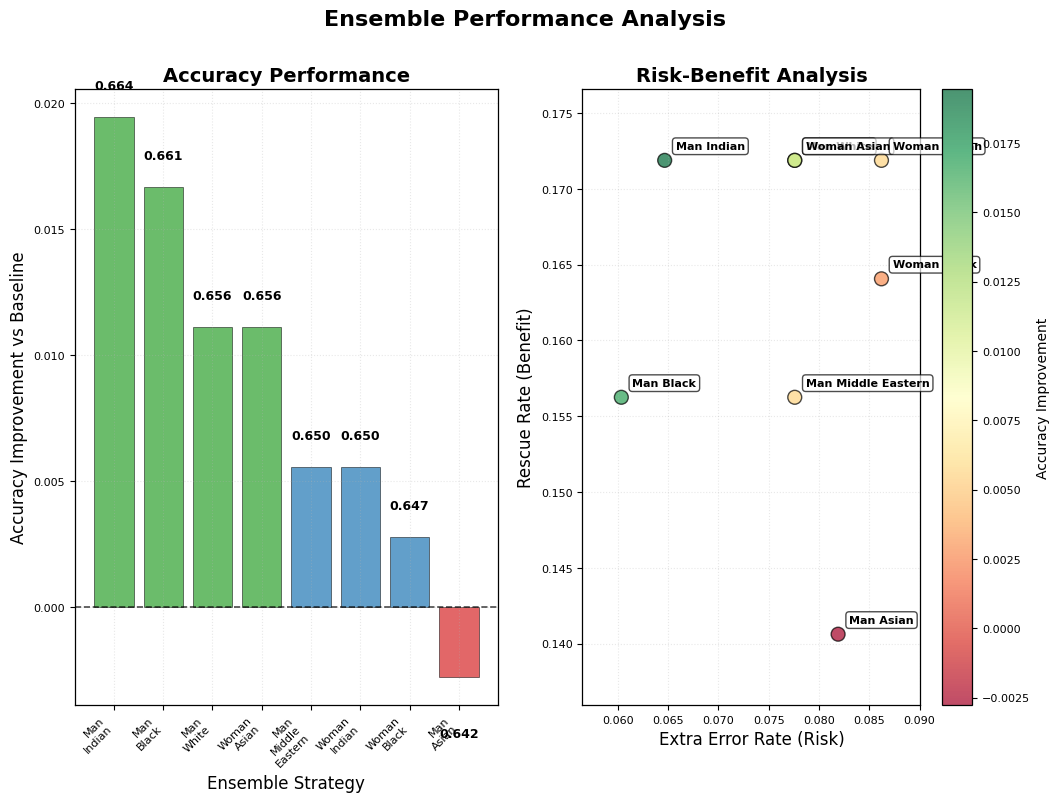

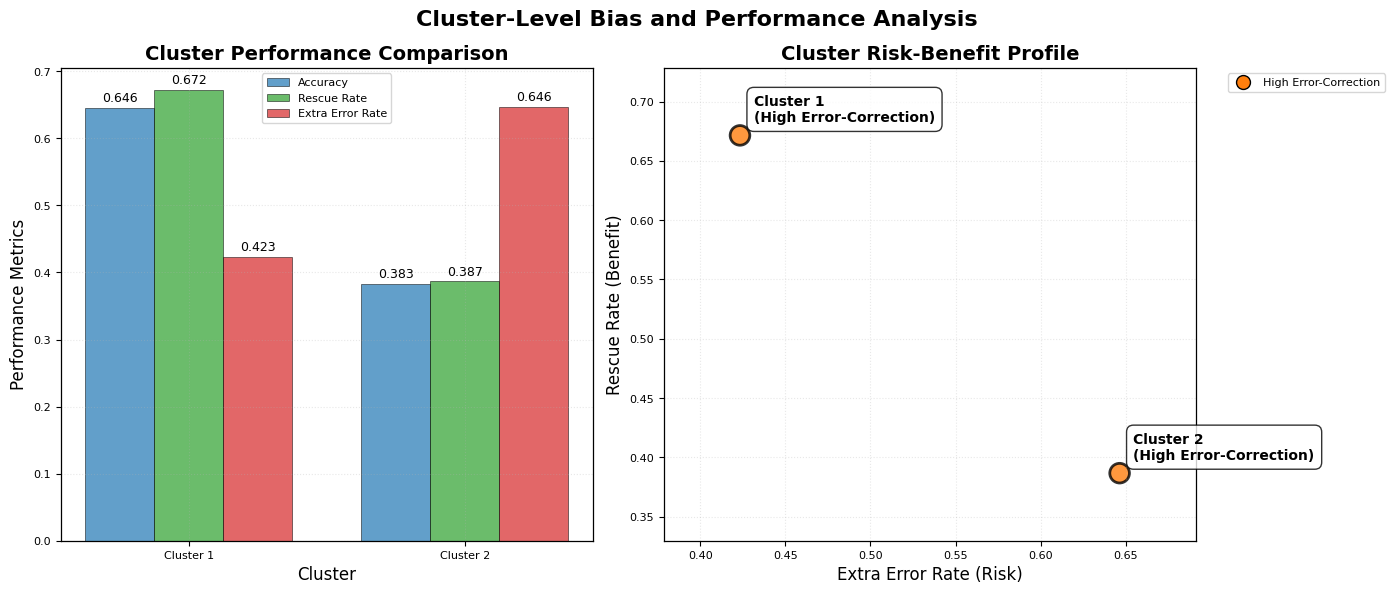

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


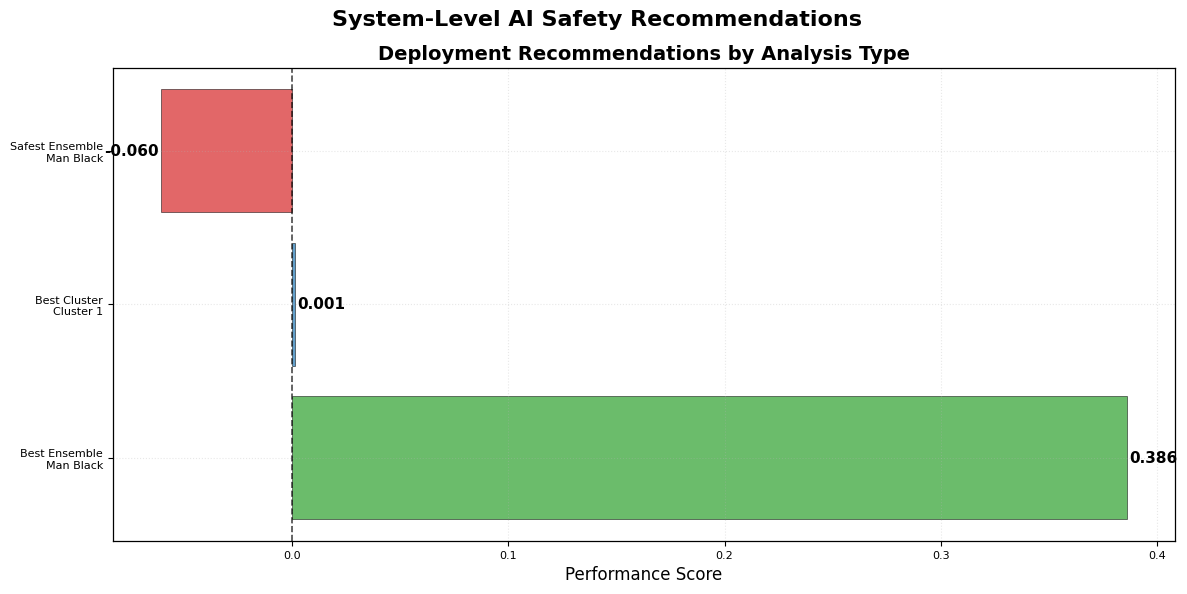


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_black
   • Best Cluster: cluster_1
   • Cognitive style analysis skipped: No cognitive style data found


In [89]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_normative_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 56 valid profiles out of 56 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
Found category values in subject: ['moral_scenarios', 'professional_law']
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (56, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.307, p=0.0214 ***
    → Positive correlation means less consistent profiles ar

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


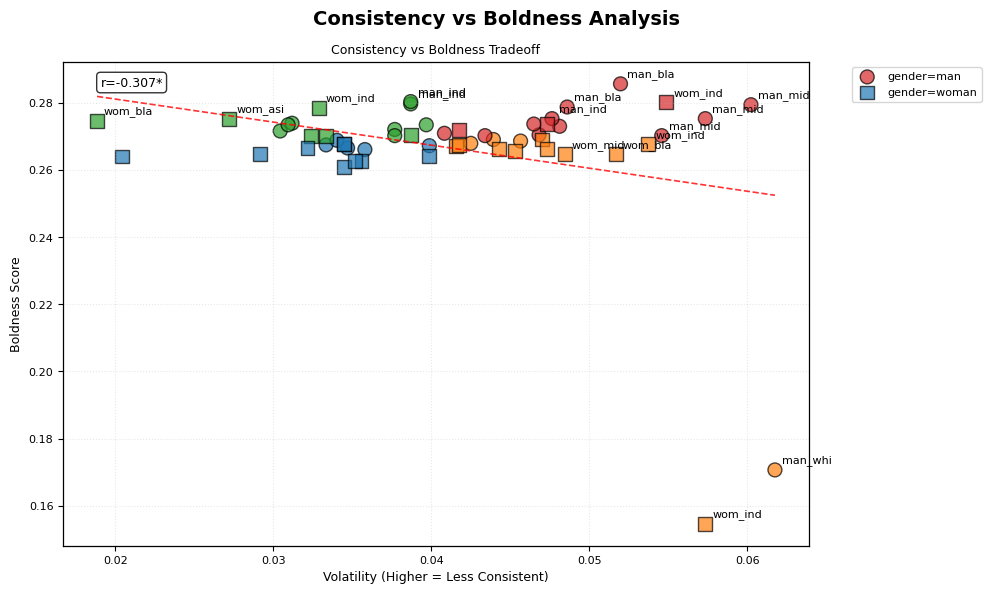

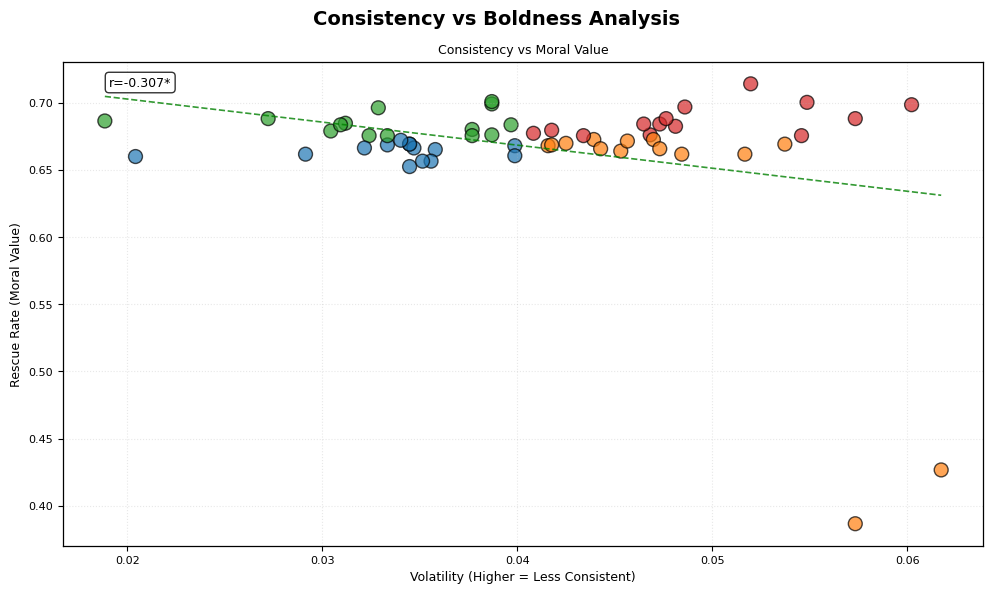

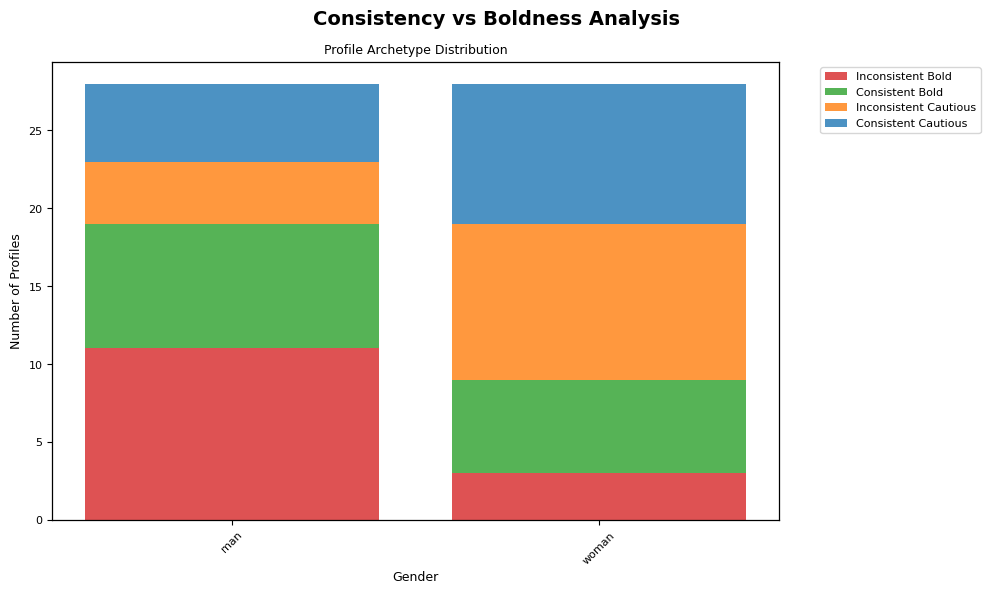

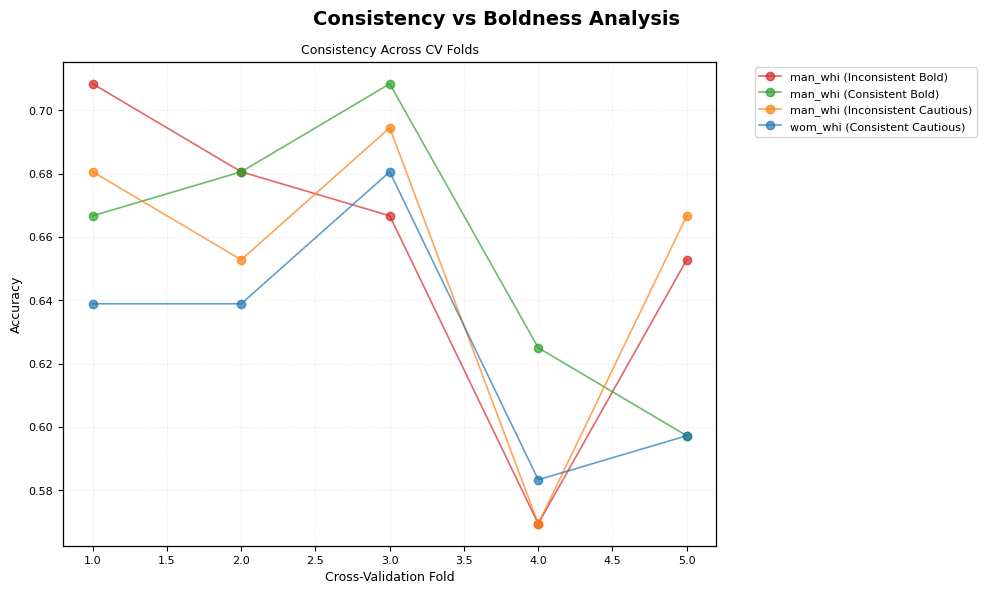

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.659 vs Consistent: 0.674
   - Strongest predictor of moral value (rescue): age_25
   - Strongest predictor of performance (accuracy): age_25
   - Bias assessment: 0 high, 2 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 56 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


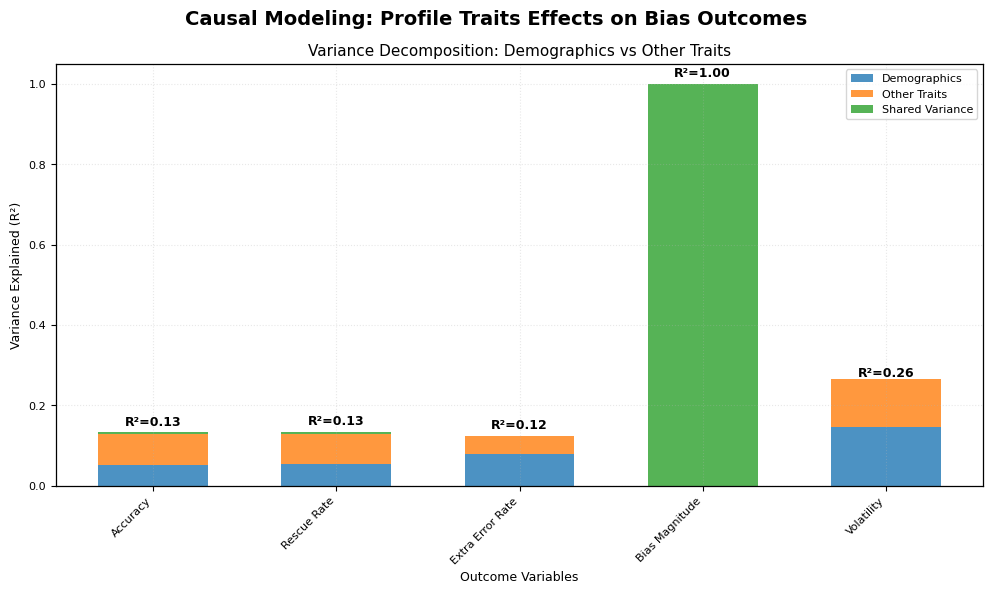

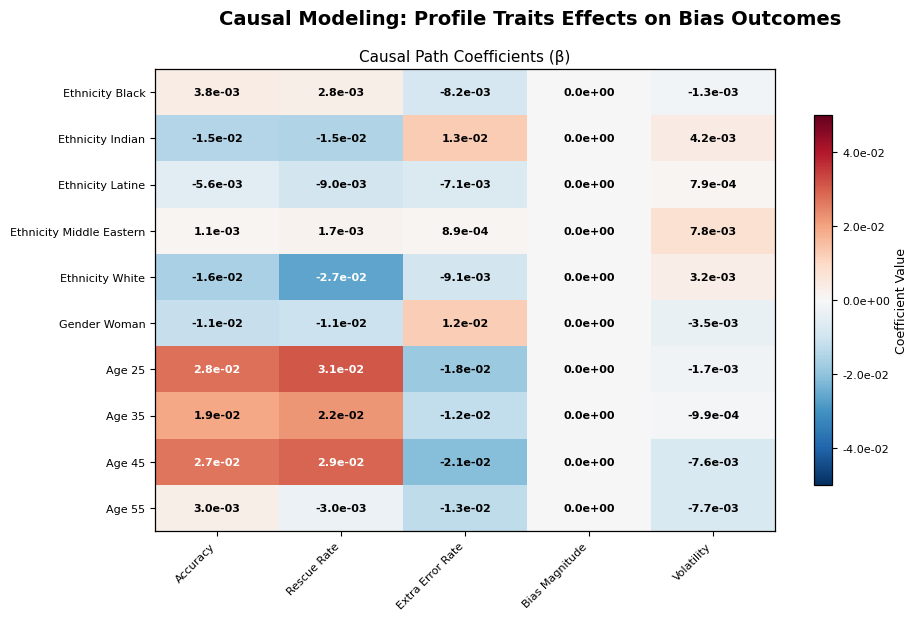

In [90]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_normative_full, person_set=PERSON_ETHNICS, case=mmlu_case)

## Zero shot Control Full

All category columns already present in merged_df
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 56/56
[INFO] 4 metadata profiles have no column in dataframe (ignored)

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 0
Statistical Significance Rate: 0.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. intersectional_white_man_vs_woman   Effect Size:  1.272 (Large)
 2. asian_vs_black                      Effect Size: -0.827 (Large)
 3. asian_vs_white                      Effect Size: -0.705 (Medium)
 4. asian_vs_middle_eastern             Effect Size: -0.571 (Medium)
 5. black_vs_latine                     Effect Size:  0.521 (Medium)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFIC

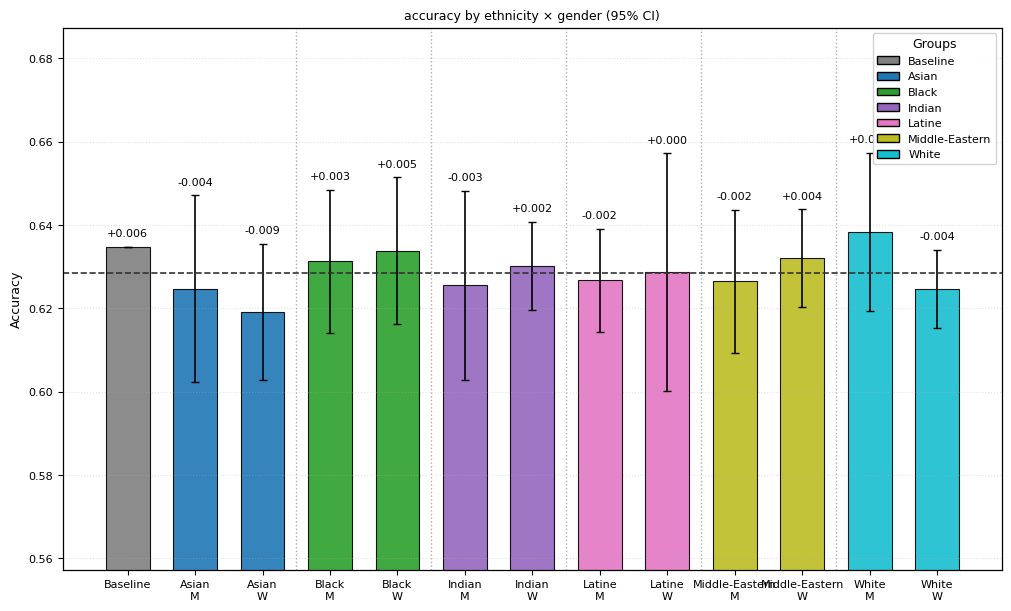

In [101]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_control_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: None
Dataset shape: (219, 60)
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (219, 60)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 55 profile columns

Performance data shape: (55, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.397260 - 0.662100
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        28  0.628995  0.014040
woman      27  0.589041  0.088949

ETHNICITY:
                count      mean       std
ethnicity                                
asian               9  0.528158  0.115652
black               9  0.632674  0.012105
indian        

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 19
  warnings.warn('covariance of constraints does not have full '
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:666: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


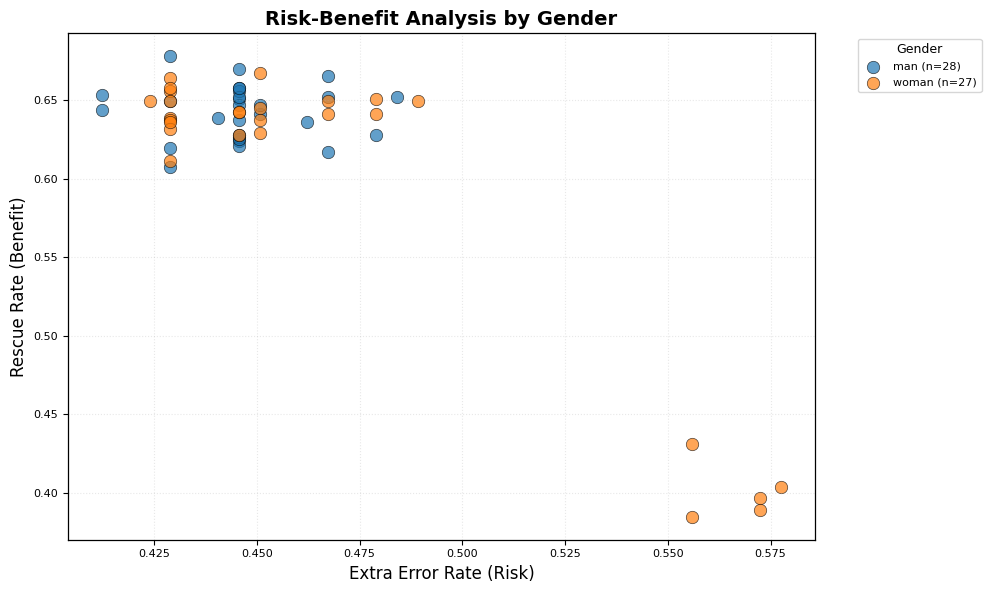


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


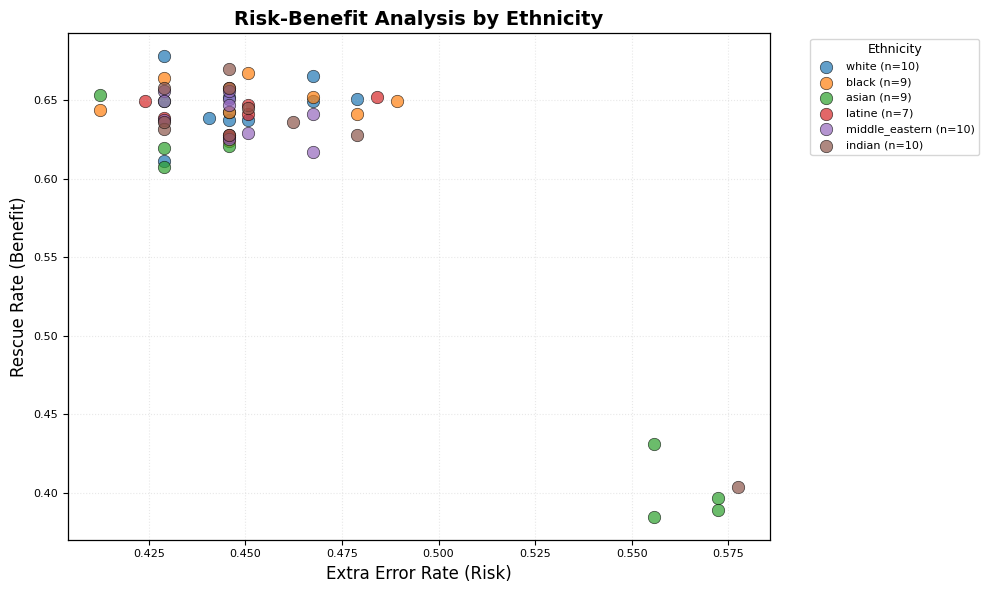


Creating risk-benefit plot for age...

Creating Pareto frontier analysis...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_1.py:736: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


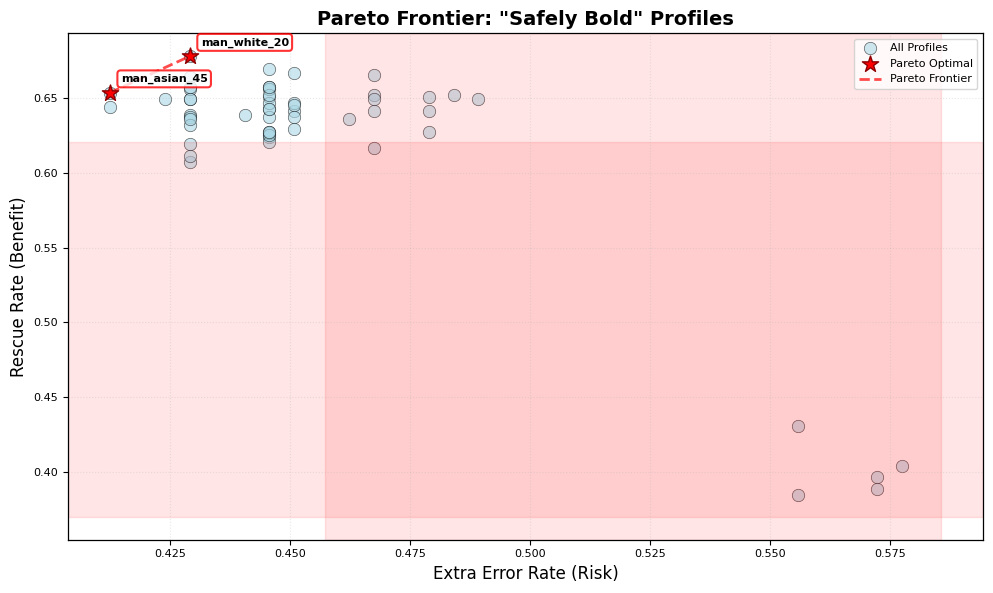


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (2 found):
  man_white_20 (profile1)
    Rescue Rate: 0.678, Extra Error Rate: 0.429
    Total Rescued: 115, Total Extra Errors: 23
  man_asian_45 (profile24)
    Rescue Rate: 0.653, Extra Error Rate: 0.412
    Total Rescued: 111, Total Extra Errors: 22

Risk-Benefit Statistics:
  Total profiles analyzed: 55
  Average rescue rate: 0.621
  Average extra error rate: 0.457
  Best rescue rate: 0.678
  Lowest extra error rate: 0.412

Profile Archetypes:
  Safest Profile: man_black_20 (profile11)
    Extra Error Rate: 0.412
  Most Beneficial Profile: man_white_20 (profile1)
    Rescue Rate: 0.678

Demographic Composition of Pareto Optimal Profiles:
  Gender:
    man: 2 (100.0%)
  Ethnicity:
    white: 1 (50.0%)
    asian: 1 (50.0%)
  Age:
=== Pareto frontier analysis completed successfully

STEP 3: EFFECT SIZE CALCULATIONS
CALCULATING ANOVA-BASED EFFECT SIZES

MAIN EFFECTS FROM ANOVA
----------------------------------------

Processi

/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3787: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/raphaelyana/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


  accuracy - black_25 vs latine_35: d = 1.414 (large)
  accuracy - black_25 vs middle_eastern_20: d = 0.949 (large)
  accuracy - black_25 vs middle_eastern_25: d = 1.342 (large)
  accuracy - black_25 vs middle_eastern_35: d = 2.121 (large)
  accuracy - black_25 vs middle_eastern_45: d = 3.606 (large)
  accuracy - black_25 vs middle_eastern_55: d = 1.414 (large)
  accuracy - black_25 vs indian_20: d = 1.038 (large)
  accuracy - black_25 vs indian_25: d = 3.536 (large)
  accuracy - black_25 vs indian_35: d = 2.043 (large)
  accuracy - black_25 vs indian_45: d = 2.828 (large)
  accuracy - black_25 vs indian_55: d = -0.447 (small)
  accuracy - black_35 vs black_25: d = -0.687 (medium)
  accuracy - black_35 vs asian_20: d = 1.225 (large)
  accuracy - black_35 vs asian_25: d = 0.922 (large)
  accuracy - black_35 vs asian_35: d = 1.136 (large)
  accuracy - black_35 vs asian_45: d = 0.866 (large)
  accuracy - black_35 vs latine_20: d = 0.525 (medium)
  accuracy - black_35 vs latine_25: d = 0.6

In [33]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_control_full, case=mmlu_case, person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (219, 60)
Category columns from CaseConfig: ['subject']
Using provided group keys: ('gender', 'ethnicity')
Dataset shape: (219, 60)

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 55 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 4 profiles
  man_indian: 5 profiles
  man_latine: 4 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 4 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 3 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.6347

Ensemble Performance by Trait Group:
----------

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1173: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


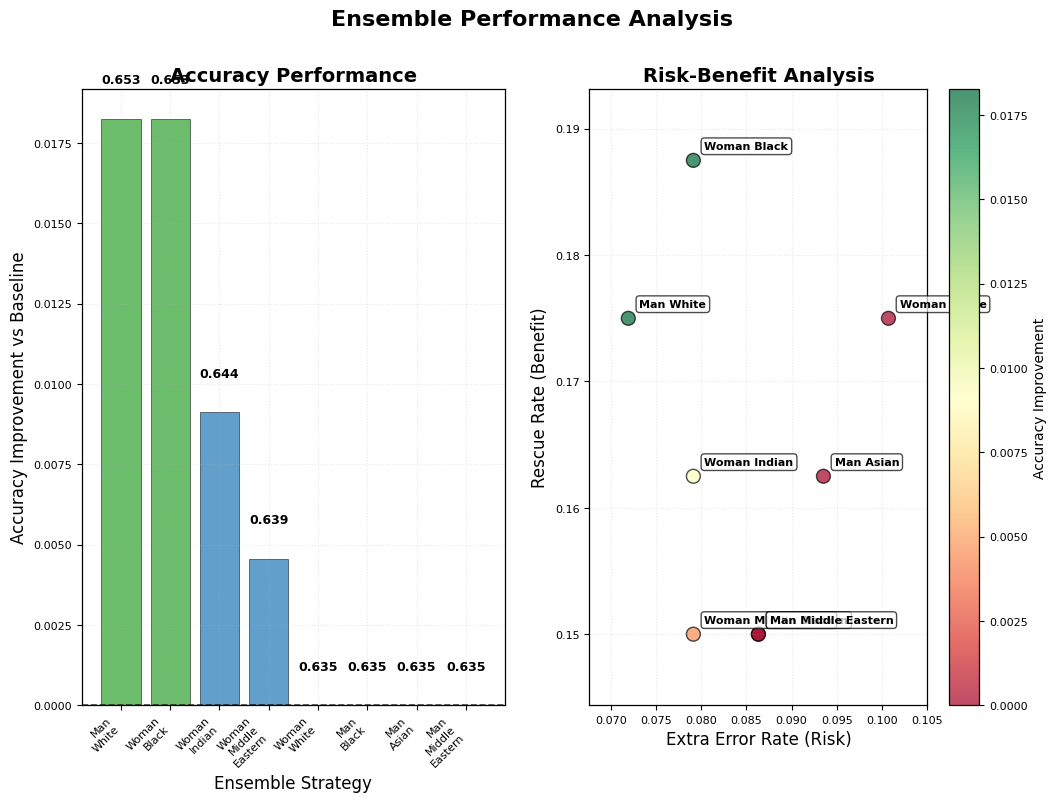

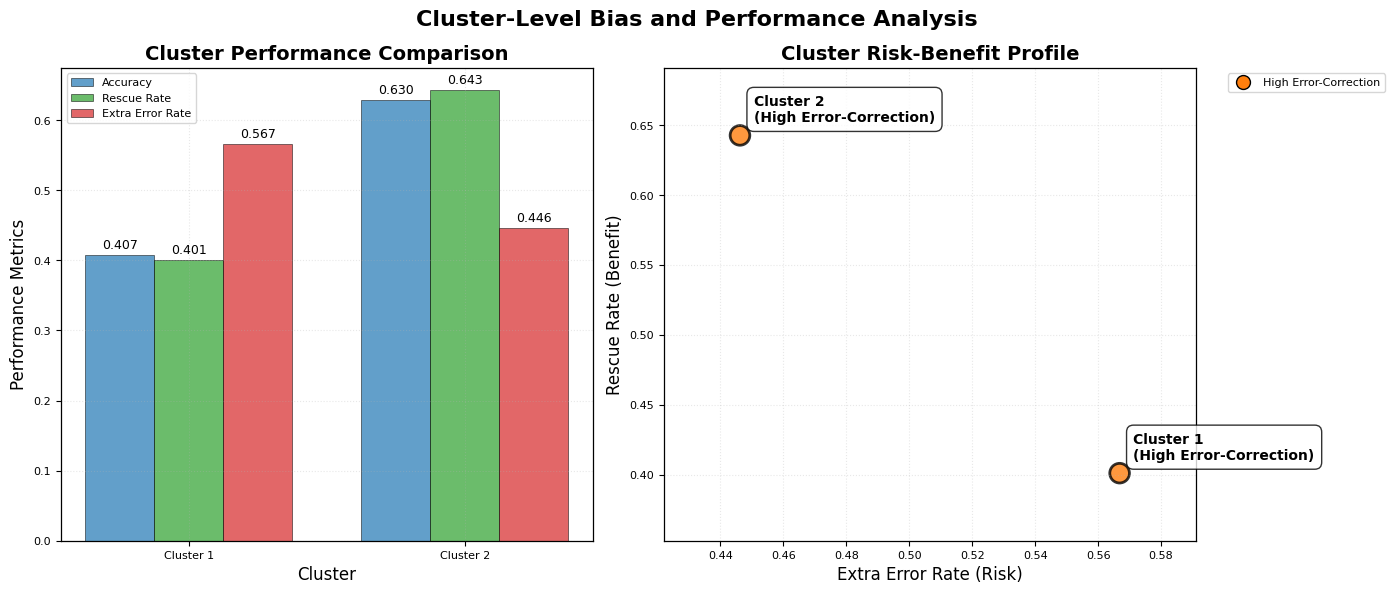

4. System-Level Recommendations...


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_2.py:1383: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


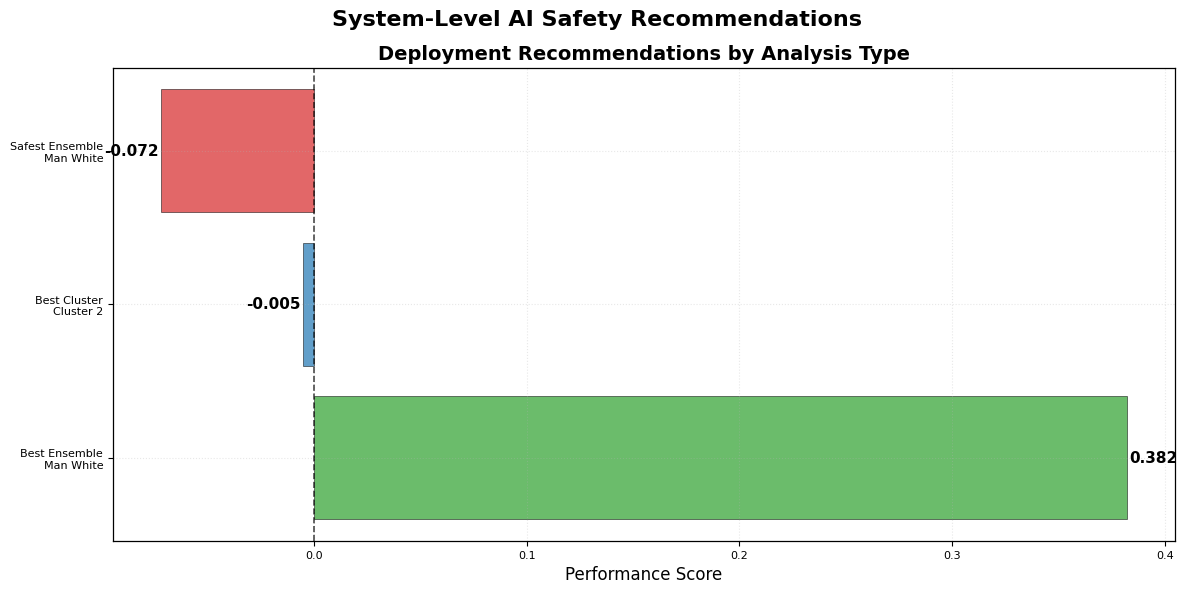


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: man_white
   • Best Cluster: cluster_2
   • Cognitive style analysis skipped: No cognitive style data found


In [34]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_control_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


EXECUTING TIER 3 ANALYSIS PIPELINE
Auto-detecting available traits from PersonSet...
Available traits detected:
  Required: ['gender', 'ethnicity']
  Optional: ['age']
Using group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 55 valid profiles out of 55 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
Found category values in subject: ['college_mathematics', 'formal_logic']
[INFO] Multi-class label space detected (4 labels). Binarizing for analysis.
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (55, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=-0.063, p=0.6473 
    → Positive correlation means less consistent profiles are b

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:657: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:674: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:714: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:745: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


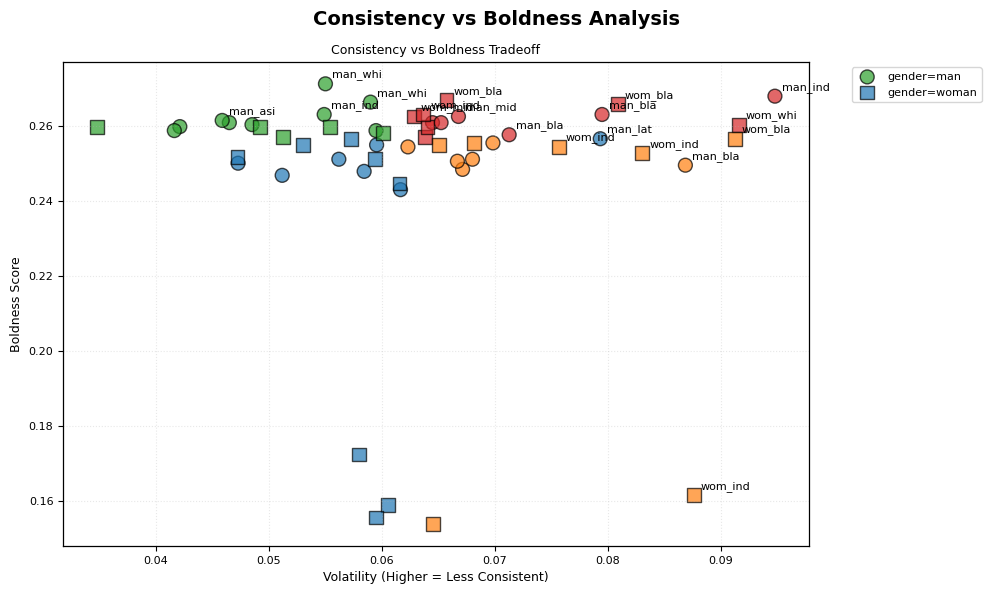

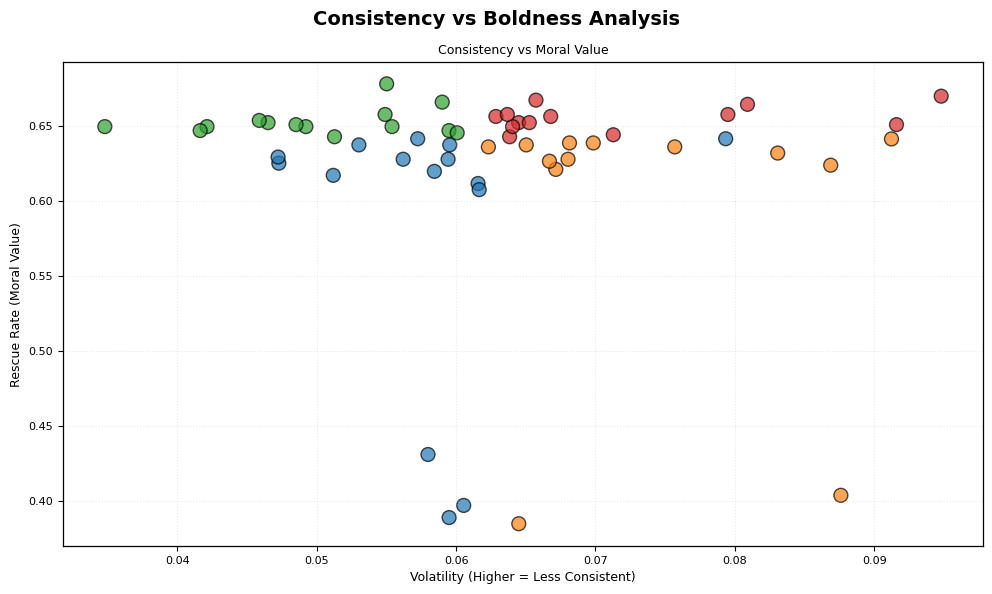

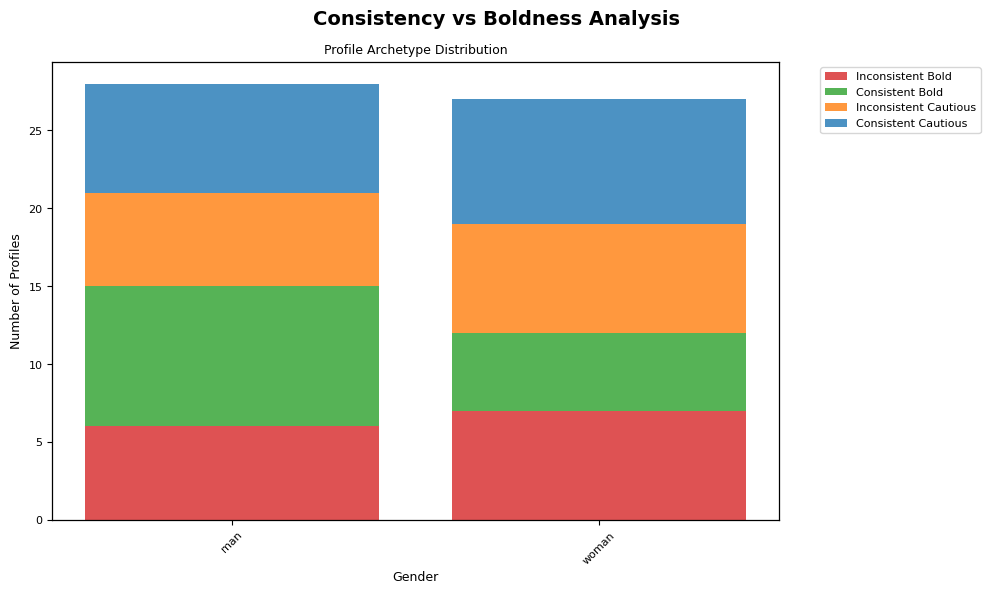

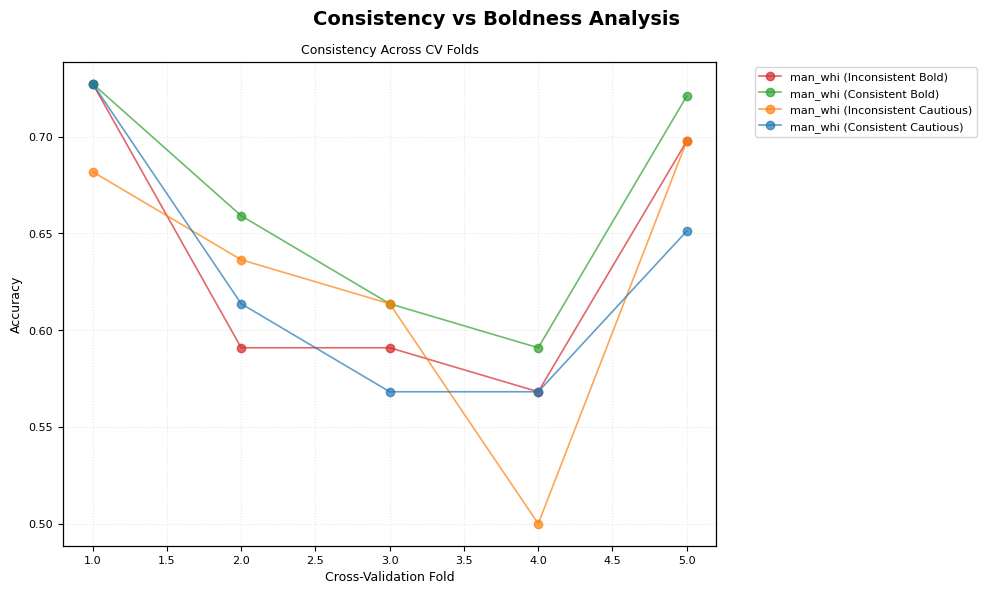

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Inconsistent profiles provide higher moral value through increased rescue rates
   - Implication: Controlled inconsistency in AI systems may be normatively justified
   - Evidence: Inconsistent rescue rate: 0.626 vs Consistent: 0.615
   - Strongest predictor of moral value (rescue): ethnicity_black
   - Strongest predictor of performance (accuracy): ethnicity_black
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 3 high, 0 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 55 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_3.py:1463: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


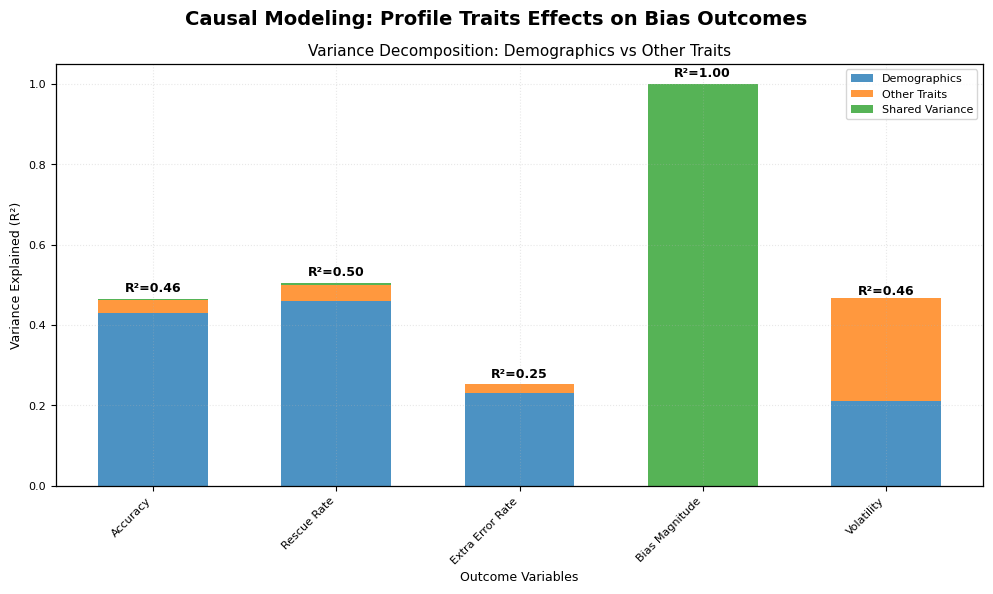

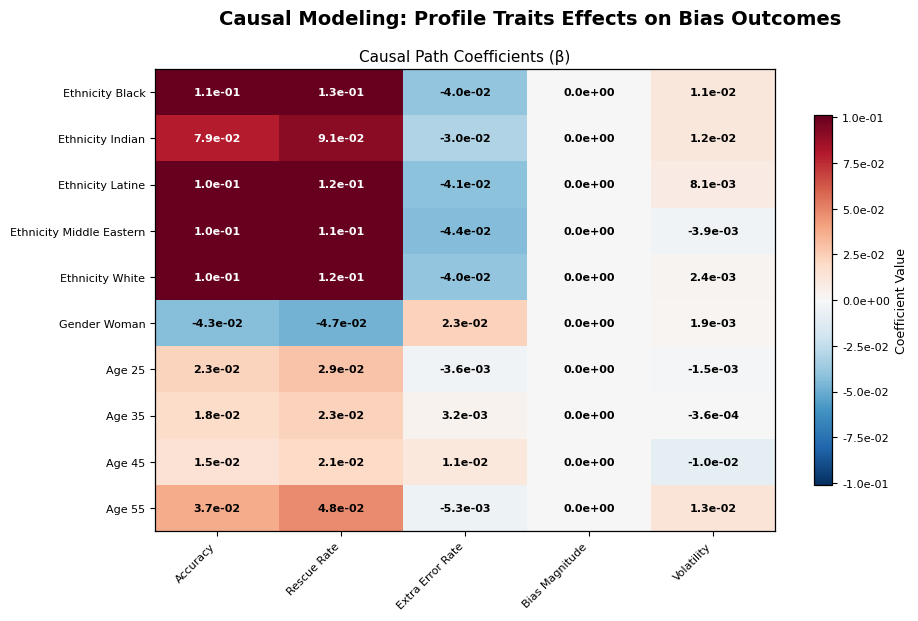

In [35]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_control_full, person_set=PERSON_ETHNICS, case=mmlu_case)

.      

.

# Few Shot - Full Dataset

## Few shot Full

On both control and normative categories.

In [ ]:
from typing import Literal
from analysis_tools import (
    load_and_merge_profiles
    )
from cases.mmlu_case import mmlu_case


ALLOWED_MODELS = {"4o_mini", "4.1_mini"}

## Set the model you want to study here
model = "4.1_mini"

if model not in ALLOWED_MODELS:
    raise ValueError(f"Invalid model: {model}. Must be one of {ALLOWED_MODELS}")
if model == "4o_mini":
    model_foldername = "openai_4o_mini"
elif model == "4.1_mini":
    model_foldername = "openai_4.1_mini"


merged_df_full = load_and_merge_profiles(
    base_file_path= f"results/{model_foldername}/few_shot/classic/results_mmlu_few_shot_3_shot_full.csv",
    role_playing_glob_pattern=f"results/{model_foldername}/few_shot/role_playing_ethnics/*/results_mmlu_few_shot_3examples_full.csv",
    sample_df=sample_mmlu_full,
    case=mmlu_case,
    extra_sample_cols=["category"]
)

merged_df_control_full = merged_df_full.loc[merged_df_full["category"] == "control"]
merged_df_normative_full = merged_df_full.loc[merged_df_full["category"] == "normative"]

FileNotFoundError: [Errno 2] No such file or directory: 'results/openai_4.1_mini/few_shot/classic/results_mmlu_few_shot_3examples_full.csv'

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_full, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_full, person_set=PERSON_ETHNICS, case=mmlu_case)

## Few shot Normative Full

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_normative_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_normative_full, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_normative_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_normative_full, person_set=PERSON_ETHNICS, case=mmlu_case)

## Few shot Control Full

In [ ]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

results = run_full_preliminary_analysis(merged_df_control_full, case=mmlu_case, df=sample_mmlu_full, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df_control_full, case=mmlu_case, person_set=PERSON_ETHNICS)

In [ ]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df_control_full,
    person_set=PERSON_ETHNICS,
    case=mmlu_case,
    group_keys=("gender", "ethnicity"))


In [ ]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_ETHNICS
from cases.mmlu_case import mmlu_case

result_tier3 = run_full_tier3_analysis(merged_df_control_full, person_set=PERSON_ETHNICS, case=mmlu_case)